# L5b Advanced: Estimation Risk in Mean-Variance Optimization

The L5b lecture ended with a warning: the closed forms carry the inverse covariance, the tangent portfolio also carries the estimated excess growth rates, and both inputs are noisy. This notebook measures how noisy. We resample the 2014 to 2024 growth rates, re-estimate the inputs on each resample, and watch how far the frontier, the minimum-variance weights, and the tangent weights move. We then ask which input is responsible, and finish by pushing every resampled portfolio through calendar year 2025 to see what the dispersion looks like in wealth.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Bootstrap the optimizer's inputs:** Resample the daily growth-rate vectors, re-estimate the mean vector and covariance matrix on each resample, and recompute the frontier and the optimal portfolios, with the caveat that resampling rows ignores serial dependence.
> - **Compare the stability of minimum-variance and tangent portfolios:** Show that the global minimum-variance weights, which depend only on the covariance, move far less across resamples than the tangent weights, which also depend on the estimated mean growth rates, and trace the difference to the mean vector.
> - **Translate weight dispersion into outcome dispersion:** Evaluate every resampled portfolio on 2025 buy-and-hold wealth and compare the spread of outcomes with the point-estimate portfolios, equal weights, and an index fund.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the course training dataset for estimation, the testing dataset for the 2025 comparison, and the thirteen firms of the L5b min-var example. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `VLQuantitativeFinancePackage.jl` package](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the datasets, the growth-rate matrix, and the long-only Markowitz solver, [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, the `LinearAlgebra`, `Statistics`, and `Random` standard libraries, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) and [the `StatsPlots.jl` package](https://docs.juliaplots.org/stable/generated/statsplots/) for figures, and [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults and the random seed:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);
Random.seed!(5660); # reproducible resamples

### Data
We load the training data (`01-03-2014` until `12-31-2024`) with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and the testing data (calendar year 2025) with [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), keep the firms with the maximum number of trading days in each, and build the training growth-rate matrix $\mathbf{G}\in\mathbb{R}^{N\times M}$ for our thirteen firms with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). We store the growth rates in the `G::Array{Float64,2}` variable, the 2025 price matrix (rows are trading days, columns are firms) in `prices_2025::Array{Float64,2}`, and the 2025 SPY prices in `spy_2025::Array{Float64,1}`:

In [3]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # M = 13 firms, chosen without looking at 2025
G, prices_2025, spy_2025 = let
    clean(d) = (n = nrow(d["AAPL"]); Dict(k => v for (k, v) ∈ d if nrow(v) == n));
    train = MyTrainingMarketDataSet() |> x-> x["dataset"] |> clean;
    test = MyTestingMarketDataSet() |> x-> x["dataset"] |> clean;
    G = log_growth_matrix(train, my_list_of_tickers, Δt = 1/252); # growth rates, N × M (units: 1/years)
    S = hcat([test[t][:, :volume_weighted_average_price] for t ∈ my_list_of_tickers]...); # 2025 prices
    (G, S, test["SPY"][:, :volume_weighted_average_price])
end;
N, M = size(G);
Δt = 1/252; g_f = 0.041; # risk-free growth rate at the end of 2024 (L5b example)
println("N = $(N) training days, M = $(M) firms, $(size(prices_2025,1)) trading days in 2025")

N = 2766 training days, M = 13 firms, 250 trading days in 2025


### Point estimates and the portfolio functions
The point estimates are the sample-mean vector and covariance of `G`. We define three portfolio functions used throughout: the closed-form unconstrained GMV portfolio, the closed-form unconstrained tangent portfolio (both from the lecture), and the long-only GMV portfolio from the course package [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}) and [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}) with a slack target. The long-only tangent portfolio is the maximum-Sharpe point of a coarse frontier sweep (the grid candidate of the L5b example), which the function `tangent_long_only` computes with a fixed number of solver calls per resample:

In [4]:
ĝ₀ = mean(G, dims=1) |> vec; Σ̂₀ = cov(G, dims=1); # point estimates

gmv_closed(Σ) = (x = Σ \ ones(M); x / sum(x));
tangent_closed(g, Σ) = (x = Σ \ (g .- g_f); x / sum(x)); # assumes sum(x) > 0

function gmv_long_only(g, Σ)
    bounds = zeros(M, 2); bounds[:,2] .= 1.0;
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ, μ = g, bounds = bounds, initial = (1/M)*ones(M), R = minimum(g)));
    solve(problem)["argmax"]
end

function tangent_long_only(g, Σ; number_of_points::Int = 31)
    bounds = zeros(M, 2); bounds[:,2] .= 1.0;
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ, μ = g, bounds = bounds, initial = (1/M)*ones(M), R = minimum(g)));
    w_gmv = solve(problem)["argmax"];
    best_w = w_gmv; best_SR = (g'*w_gmv - g_f)/sqrt(w_gmv'*Σ*w_gmv);
    for target ∈ range(g'*w_gmv, stop = maximum(g) - 1e-4, length = number_of_points)
        problem.R = target;
        w = try solve(problem)["argmax"] catch err; err isa AssertionError ? continue : rethrow(); end
        SR = (g'*w - g_f)/sqrt(w'*Σ*w);
        if SR > best_SR; best_SR = SR; best_w = w; end
    end
    best_w
end;

w_gmv₀ = gmv_long_only(ĝ₀, Σ̂₀); w_tan₀ = tangent_long_only(ĝ₀, Σ̂₀);
println("Point-estimate long-only GMV: E[g] = $(round(ĝ₀'*w_gmv₀, digits=4)) 1/yr; long-only tangent: E[g] = $(round(ĝ₀'*w_tan₀, digits=4)) 1/yr")

Point-estimate long-only GMV: E[g] = 0.0818 1/yr; long-only tangent: E[g] = 0.4272 1/yr


___

## 1. Resampling the inputs
The bootstrap treats the $N$ observed daily growth-rate vectors as the population and draws $N$ rows with replacement to form a resampled matrix $\mathbf{G}^{*}$; the estimates on $\mathbf{G}^{*}$ vary from resample to resample as the true estimates would vary across hypothetical alternative histories, if the days were independent draws. They are not quite: daily growth rates carry some serial dependence and volatility clustering (L3a, and the L5a advanced material on rolling correlations), which a block bootstrap would preserve and the row bootstrap ignores, so read the spreads below as a lower bound on the real uncertainty. We draw $B$ resamples and, for each, store the mean vector, the covariance, and the four portfolios in the `boot::NamedTuple` variable (each field is a matrix or vector indexed by resample):

In [5]:
boot = let
    B = 100; # number of resamples (each long-only tangent portfolio costs a frontier sweep)
    ĝ_b = Array{Float64,2}(undef, M, B); Σ_b = Array{Array{Float64,2},1}(undef, B);
    W_gmv_closed = Array{Float64,2}(undef, M, B); W_tan_closed = Array{Float64,2}(undef, M, B);
    W_gmv_lo = Array{Float64,2}(undef, M, B); W_tan_lo = Array{Float64,2}(undef, M, B);
    for k ∈ 1:B
        rows = rand(1:N, N); # draw N rows with replacement
        Gk = G[rows, :]; gk = mean(Gk, dims=1) |> vec; Σk = cov(Gk, dims=1);
        ĝ_b[:,k] = gk; Σ_b[k] = Σk;
        W_gmv_closed[:,k] = gmv_closed(Σk); W_tan_closed[:,k] = tangent_closed(gk, Σk);
        W_gmv_lo[:,k] = gmv_long_only(gk, Σk); W_tan_lo[:,k] = tangent_long_only(gk, Σk);
    end
    (B = B, ĝ = ĝ_b, Σ = Σ_b, gmv_closed = W_gmv_closed, tan_closed = W_tan_closed, gmv_long_only = W_gmv_lo, tan_long_only = W_tan_lo)
end;
println("Resamples: $(boot.B)")

Resamples: 100


How much do the inputs themselves move? Let's summarize the resampled mean growth rates and growth-rate standard deviations for each firm, as the point estimate with a bootstrap standard error [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/):

In [6]:
let
    σ_b = hcat([sqrt.(diag(Σ)) for Σ ∈ boot.Σ]...); # growth-rate standard deviations per resample
    df = DataFrame(ticker = my_list_of_tickers, g_mean = round.(ĝ₀, digits=3), se_g_mean = round.(std(boot.ĝ, dims=2) |> vec, digits=3),
        σ_g = round.(sqrt.(diag(Σ̂₀)), digits=3), se_σ_g = round.(std(σ_b, dims=2) |> vec, digits=3));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- ----------- --------- ---------
  ticker    g_mean   se_g_mean       σ_g    se_σ_g 
  String   Float64     Float64   Float64   Float64 
 -------- --------- ----------- --------- ---------
    AAPL     0.233       0.067     3.723     0.079
    MSFT     0.222       0.061     3.421     0.087
    INTC    -0.023       0.083     4.672     0.225
      MU     0.127       0.119     6.454     0.138
     AMD     0.312       0.153     7.529     0.184
    NVDA     0.532       0.114     6.169     0.172
      GS     0.106       0.076     3.898     0.102
     BAC      0.09       0.089     4.266     0.115
     WFC      0.04       0.087     4.211     0.135
       C     0.026       0.091     4.518     0.161
       F    -0.041       0.103     5.101     0.165
      GM     0.027         0.1     5.102     0.159
     JNJ     0.041       0.047     2.441     0.074
 -------- --------- ----------- --------- ---------


The standard error of a mean growth rate is of the same order as the mean itself for most firms, while the standard deviations are pinned down to a few percent. That asymmetry, well known since Merton (1980), is the whole story of what follows: with $N$ days of data the standard error of the mean scales like $\sigma_{g}/\sqrt{N}$ and stays large because $\sigma_{g}$ is several per year, while the variance estimate improves with every observation.
___

## 2. Frontier and weight dispersion
First the frontier. For each resample we draw the efficient branch of the unconstrained hyperbola from its closed form (fast), together with the point-estimate frontier, to see how far the whole curve moves:

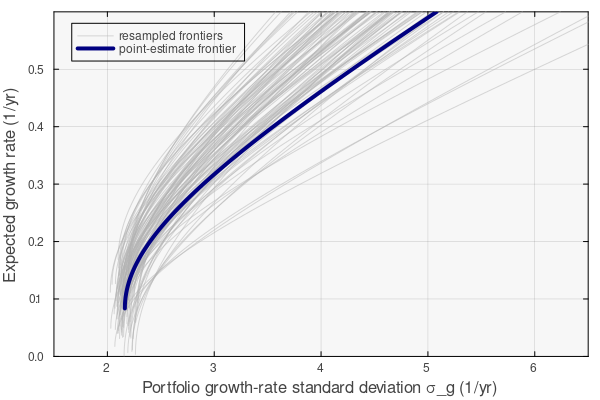

In [7]:
let
    function hyperbola(g, Σ)
        x = Σ \ ones(M); y = Σ \ g; a = ones(M)'*x; b = ones(M)'*y; c = g'*y; d = a*c - b^2;
        @assert d > 0 # the resampled means are not all equal
        gr = range(b/a, stop = 0.6, length = 80) |> collect;
        (sqrt.((a .* gr.^2 .- 2*b .* gr .+ c) ./ d), gr)
    end
    plot()
    for k ∈ 1:boot.B
        σr, gr = hyperbola(boot.ĝ[:,k], boot.Σ[k]);
        plot!(σr, gr, c = :gray70, alpha = 0.5, lw = 1, label = (k == 1 ? "resampled frontiers" : ""))
    end
    σ0, g0 = hyperbola(ĝ₀, Σ̂₀);
    plot!(σ0, g0, c = :navy, lw = 4, label = "point-estimate frontier")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", xlim = (1.5, 6.5), ylim = (0.0, 0.6), legend = :topleft)
end

The vertex barely moves; the branch fans out as the target rises, because reaching a higher target relies more and more on the estimated means. Now the weights. Let's compare, asset by asset, the spread of the long-only GMV weights with the spread of the long-only tangent weights across resamples, as box plots [using the `boxplot(...)` function](https://docs.juliaplots.org/stable/generated/statsplots/#Box-plots) from StatsPlots (the unconstrained closed forms are shown after):

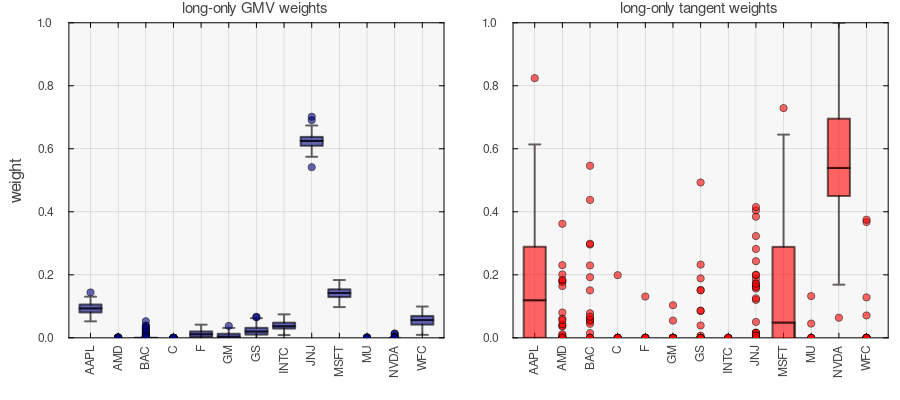

In [8]:
let
    labels = repeat(my_list_of_tickers, inner = boot.B);
    p1 = boxplot(labels, vec(boot.gmv_long_only'), legend = false, c = :navy, alpha = 0.6, xrotation = 90, title = "long-only GMV weights", titlefontsize = 10, ylabel = "weight", ylim = (0, 1))
    p2 = boxplot(labels, vec(boot.tan_long_only'), legend = false, c = :red, alpha = 0.6, xrotation = 90, title = "long-only tangent weights", titlefontsize = 10, ylim = (0, 1))
    plot(p1, p2, layout = (1, 2), size = (900, 400), bottom_margin = 8Plots.mm, left_margin = 5Plots.mm)
end

The GMV weights are tight; the tangent weights swing between zero and most of the budget for the high-growth names, because which firm has the highest estimated mean changes from resample to resample. Let's put a number on it: for each portfolio, the absolute deviation of its weights from their bootstrap average, summed over assets (a turnover-like distance), reported as its mean and its median across resamples [using the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) and [the `median(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.median). We also count the resamples in which the closed-form tangent portfolio's normalizing constant $\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g}^{-1}(\hat{\mathbf{g}}-g_{f}\mathbf{1})$ is small (below one tenth of its point-estimate value) or negative, which is the condition of the lecture's tangency proposition failing or nearly failing:

In [9]:
distances(W) = vec(sum(abs.(W .- median(W, dims=2)), dims=1)); # per resample: Σᵢ |wᵢ - median(wᵢ)|
dispersion(W) = mean(distances(W)); # mean across resamples
let
    df = DataFrame(portfolio = ["GMV (closed form)", "tangent (closed form)", "GMV (long only)", "tangent (long only)"],
        mean_dist = round.([dispersion(boot.gmv_closed), dispersion(boot.tan_closed), dispersion(boot.gmv_long_only), dispersion(boot.tan_long_only)], digits=3),
        median_dist = round.([median(distances(boot.gmv_closed)), median(distances(boot.tan_closed)), median(distances(boot.gmv_long_only)), median(distances(boot.tan_long_only))], digits=3),
        max_abs_w = round.([maximum(abs.(boot.gmv_closed)), maximum(abs.(boot.tan_closed)), maximum(abs.(boot.gmv_long_only)), maximum(abs.(boot.tan_long_only))], digits=2));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))

    κ₀ = sum(Σ̂₀ \ (ĝ₀ .- g_f)); # point-estimate normalizing constant
    κ = [sum(boot.Σ[k] \ (boot.ĝ[:,k] .- g_f)) for k ∈ 1:boot.B];
    println("Tangency normalizing constant: point estimate = $(round(κ₀, digits=4)); resamples with κ ≤ 0: $(count(κ .≤ 0)); with 0 < κ < κ₀/10: $(count(0 .< κ .< κ₀/10)) of $(boot.B)")
end

 ----------------------- ----------- ------------- -----------
              portfolio   mean_dist   median_dist   max_abs_w 
                 String     Float64       Float64     Float64 
 ----------------------- ----------- ------------- -----------
      GMV (closed form)       0.206         0.197        0.68
  tangent (closed form)      48.497         7.102      194.64
        GMV (long only)        0.11         0.105         0.7
    tangent (long only)       0.572         0.533         1.0
 ----------------------- ----------- ------------- -----------
Tangency normalizing constant: point estimate = 0.0091; resamples with κ ≤ 0: 15; with 0 < κ < κ₀/10: 2 of 100


The unconstrained tangent portfolio is the least stable object here by a wide margin: even its median distance is large, and its mean is dominated by resamples in which the normalizing constant comes close to zero and the weights explode to many times the budget. In a noticeable fraction of resamples the constant is negative: the resampled GMV portfolio earns less than $g_{f}$ in expectation, and the closed form then returns the minimum-Sharpe portfolio rather than the maximum (the proposition's condition fails), even though individual firms with positive excess growth still exist. The point estimate itself is close to that boundary. The long-only constraint tames the dispersion of both portfolios; that is the practical argument for constraints, independent of any belief about short selling.
___

## 3. Which input is responsible?
The tangent portfolio depends on both $\hat{\mathbf{g}}$ and $\hat{\mathbf{\Sigma}}_{g}$. To attribute its dispersion, we recompute the closed-form tangent weights holding one input at its point estimate while the other takes its resampled values: means resampled with the covariance fixed, and covariance resampled with the means fixed. Whichever experiment reproduces the dispersion of the fully resampled tangent portfolio is the input that matters:

In [10]:
let
    W_means_only = hcat([tangent_closed(boot.ĝ[:,k], Σ̂₀) for k ∈ 1:boot.B]...);
    W_cov_only = hcat([tangent_closed(ĝ₀, boot.Σ[k]) for k ∈ 1:boot.B]...);
    df = DataFrame(experiment = ["means and covariance resampled", "means resampled, covariance fixed", "covariance resampled, means fixed"],
        mean_dist = round.([dispersion(boot.tan_closed), dispersion(W_means_only), dispersion(W_cov_only)], digits=3),
        median_dist = round.([median(distances(boot.tan_closed)), median(distances(W_means_only)), median(distances(W_cov_only))], digits=3));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------------------------------- ----------- -------------
                         experiment   mean_dist   median_dist 
                             String     Float64       Float64 
 ----------------------------------- ----------- -------------
     means and covariance resampled      48.497         7.102
  means resampled, covariance fixed      37.507         7.273
  covariance resampled, means fixed        1.73         1.507
 ----------------------------------- ----------- -------------


Almost all of the tangent portfolio's instability comes through the mean vector; the covariance contributes a small fraction. This is why the lecture calls the expected growth rates the noisiest input, why minimum-variance portfolios (which ignore them) are the stable baseline, and why the L5a advanced material on covariance shrinkage, useful as it is, cannot fix the tangent portfolio on its own.
___

## 4. What the dispersion looks like in 2025
Finally, we push every resampled long-only GMV and tangent portfolio through calendar year 2025 as a buy-and-hold portfolio, $W_{T}/W_{0}=\sum_{i}w_{i}S_{i}(T)/S_{i}(0)$, and record the year-end wealth ratio and the realized growth-rate standard deviation of the wealth path, next to the point-estimate portfolios, equal weights, and SPY, in the `oos::DataFrame` variable. The universe and the weights were fixed before 2025; only the resample varies:

In [11]:
oos = let
    ratio = prices_2025 ./ prices_2025[1,:]'; # S_i(t)/S_i(0)
    wealth(w) = ratio*w; # scaled buy-and-hold wealth path
    stats(w) = (W = wealth(w); (W[end], std(diff(log.(W)) ./ Δt)));
    df = DataFrame(portfolio = String[], W_T = Float64[], σ_g_2025 = Float64[]);
    for k ∈ 1:boot.B
        WT, s = stats(boot.gmv_long_only[:,k]); push!(df, (portfolio = "GMV, resampled", W_T = WT, σ_g_2025 = s));
        WT, s = stats(boot.tan_long_only[:,k]); push!(df, (portfolio = "tangent, resampled", W_T = WT, σ_g_2025 = s));
    end
    for (name, w) ∈ [("GMV, point estimate", w_gmv₀), ("tangent, point estimate", w_tan₀), ("equal weights", (1/M)*ones(M))]
        WT, s = stats(w); push!(df, (portfolio = name, W_T = WT, σ_g_2025 = s));
    end
    W_spy = spy_2025 ./ spy_2025[1]; push!(df, (portfolio = "SPY", W_T = W_spy[end], σ_g_2025 = std(diff(log.(W_spy)) ./ Δt)));
    df; # return
end;
let
    summary = combine(groupby(oos, :portfolio, sort = true), :W_T => (x -> round(median(x), digits=3)) => :med_W_T,
        :W_T => (x -> round(quantile(x, 0.05), digits=3)) => :q05_W_T, :W_T => (x -> round(quantile(x, 0.95), digits=3)) => :q95_W_T,
        :σ_g_2025 => (x -> round(median(x), digits=3)) => :med_σ_g)
    pretty_table(summary, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------------------- --------- --------- --------- ---------
                portfolio   med_W_T   q05_W_T   q95_W_T   med_σ_g 
                   String   Float64   Float64   Float64   Float64 
 ------------------------- --------- --------- --------- ---------
      GMV, point estimate     1.377     1.377     1.377     1.996
           GMV, resampled     1.374     1.362     1.394     1.992
                      SPY     1.169     1.169     1.169     2.206
            equal weights     1.592     1.592     1.592     3.487
  tangent, point estimate     1.288     1.288     1.288     5.025
       tangent, resampled     1.294     1.213      1.44     4.527
 ------------------------- --------- --------- --------- ---------


And as a picture, the 2025 year-end wealth ratio against the realized 2025 growth-rate standard deviation for every resampled portfolio, with the point estimates, equal weights, and SPY marked:

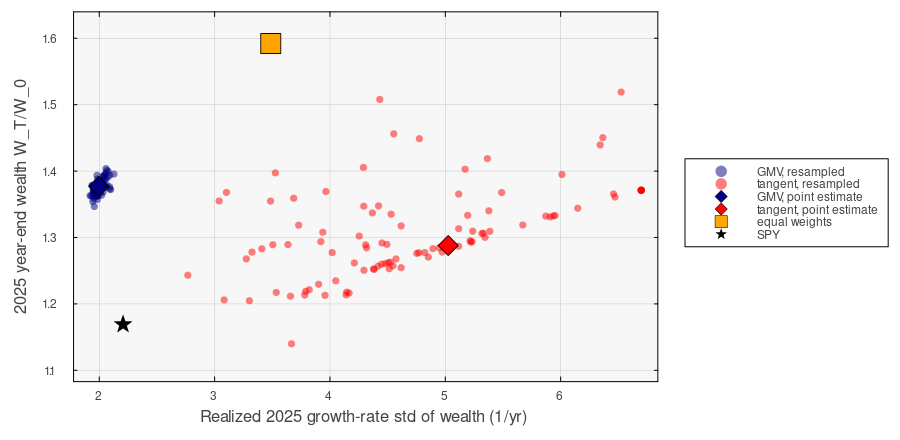

In [12]:
let
    sub(name) = filter(:portfolio => ==(name), oos);
    scatter(sub("GMV, resampled").σ_g_2025, sub("GMV, resampled").W_T, ms = 4, c = :navy, alpha = 0.5, msw = 0, label = "GMV, resampled")
    scatter!(sub("tangent, resampled").σ_g_2025, sub("tangent, resampled").W_T, ms = 4, c = :red, alpha = 0.5, msw = 0, label = "tangent, resampled")
    for (name, c, m) ∈ [("GMV, point estimate", :navy, :diamond), ("tangent, point estimate", :red, :diamond), ("equal weights", :orange, :square), ("SPY", :black, :star5)]
        scatter!(sub(name).σ_g_2025, sub(name).W_T, ms = 10, c = c, marker = m, label = name)
    end
    plot!(xlabel = "Realized 2025 growth-rate std of wealth (1/yr)", ylabel = "2025 year-end wealth W_T/W_0", legend = :outerright, size = (900, 440),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm, ylim = (0.95*minimum(oos.W_T), 1.03*maximum(oos.W_T)))
end

The resampled GMV portfolios cluster: similar weights, similar 2025 outcomes, and the lowest realized standard deviations in the plot. The resampled tangent portfolios scatter across a wide range of outcomes because they are different portfolios, concentrated in whichever names the resample favored. One year of data cannot say which of them was "right"; the spread itself is the point, and it was visible before 2025 began.
___

## Summary

This notebook measured the estimation risk the lecture warned about: resampling the training data moves the mean growth rates by amounts comparable to the means themselves, and the tangent portfolio, which depends on them, moves with them, while the minimum-variance portfolio, which does not, stays put.

> __Key Takeaways:__
>
> - **Means are the noisy input, variances are not:** The bootstrap standard error of a mean growth rate is of the order of the mean itself, while the growth-rate standard deviations are pinned down to a few percent, and holding one input fixed at a time shows that almost all of the tangent portfolio's dispersion enters through the mean vector.
> - **Minimum-variance portfolios are stable, tangent portfolios are not:** Across resamples the long-only GMV weights barely move and the unconstrained tangent weights swing by multiples of the budget, and the long-only constraint reduces the dispersion of both, which is a practical argument for constraints that has nothing to do with views on short selling.
> - **Weight dispersion becomes outcome dispersion:** Pushed through 2025, the resampled minimum-variance portfolios cluster with the lowest realized risk while the resampled tangent portfolios scatter across a wide range of wealth outcomes, a spread that was measurable before the year began.

The lecture's baselines, equal weights and the minimum-variance portfolio, are the portfolios an honest estimate of the inputs leaves standing; L6a's single-index model is one way to reduce the number of things that must be estimated.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___